Loaded CSV: telecom_churn.csv
Data shape: (3333, 11)
   Churn  AccountWeeks  ContractRenewal  DataPlan  DataUsage  CustServCalls  \
0      0           128                1         1        2.7              1   
1      0           107                1         1        3.7              1   
2      0           137                1         0        0.0              0   
3      0            84                0         0        0.0              2   
4      0            75                0         0        0.0              3   

   DayMins  DayCalls  MonthlyCharge  OverageFee  RoamMins  
0    265.1       110           89.0        9.87      10.0  
1    161.6       123           82.0        9.78      13.7  
2    243.4       114           52.0        6.06      12.2  
3    299.4        71           57.0        3.10       6.6  
4    166.7       113           41.0        7.42      10.1  

Detected target column: Churn
Churn
0    2850
1     483
Name: count, dtype: int64

After preprocessing, feature

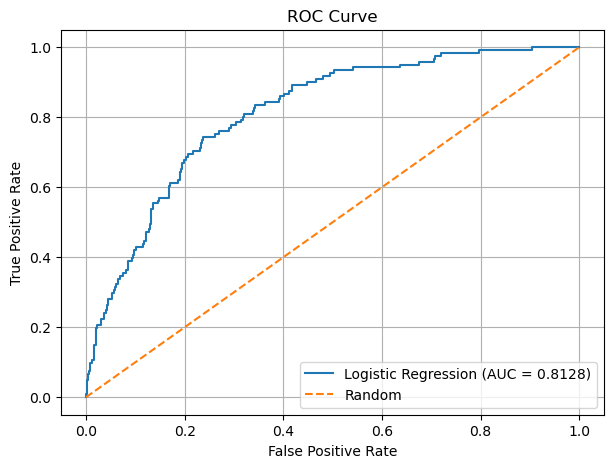

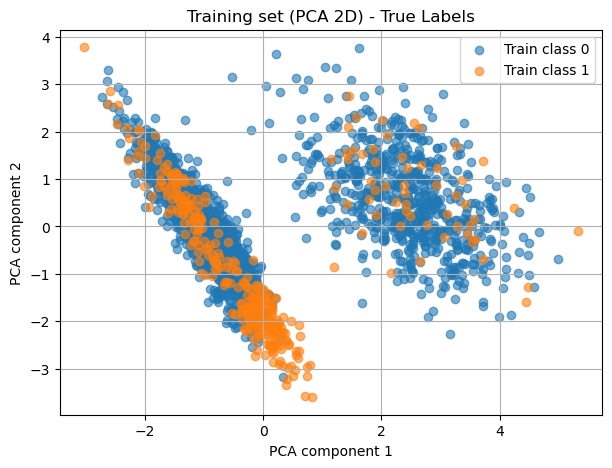

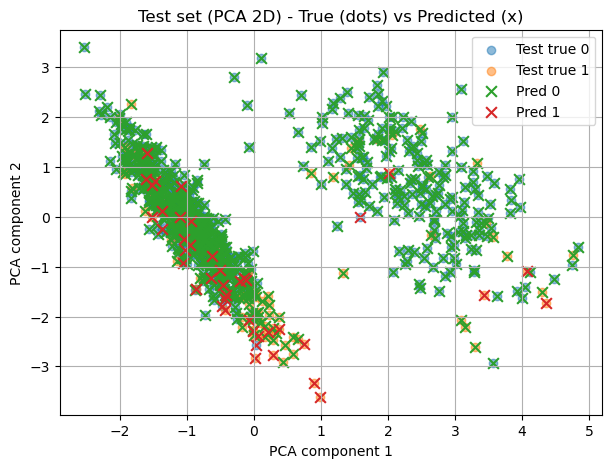

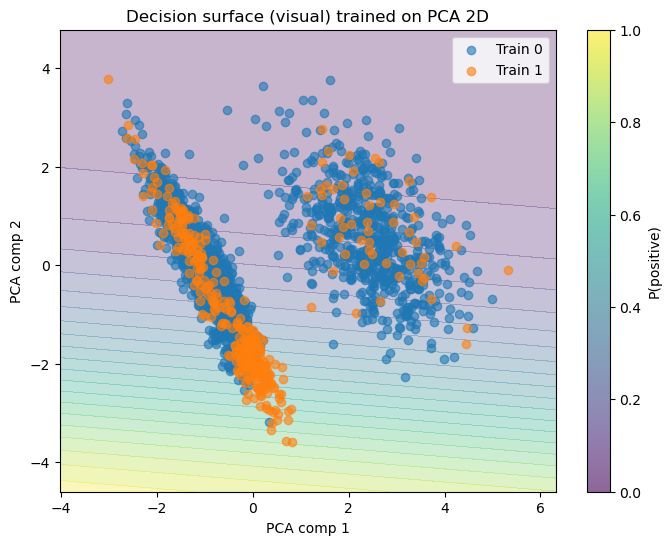


Saved model and features to ./output_lr

Done. If you want me to run this and show the outputs for your uploaded CSV now, tell me and I will run it.


In [11]:
"""
Logistic Regression workflow (Steps 1 → 7)
Reads a CSV file and performs:
1) Use a dataset (customer churn / loan / cancer) to build Logistic Regression
2) Preprocess (imputation, encoding, StandardScaler)
3) Split into train/test
4) Train logistic regression and predict
5) Evaluate using confusion matrix, accuracy, precision, recall, F1
6) Plot ROC curve and compute AUC
7) Visualize training & testing sets with 2D scatter (PCA) and a decision surface for illustration

Default CSV path: /mnt/data/telecom_churn.csv
Change `CSV_PATH` at the top if you want to use another file.

Run in a Jupyter cell or as a Python script. Plots use matplotlib.
"""

# -----------------------
# Step 0: imports & settings
# -----------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, classification_report, roc_curve, auc)
from sklearn.decomposition import PCA
import joblib

RANDOM_STATE = 42
plt.rcParams.update({'figure.max_open_warning': 0})

# -----------------------
# Config: change this if needed
# -----------------------
CSV_PATH = 'telecom_churn.csv'  # <<-- change this path to your file if needed
TARGET_CANDIDATES = ['Churn', 'churn', 'target', 'Target', 'label', 'Label', 'Outcome', 'outcome']
OUTPUT_DIR = './output_lr'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -----------------------
# Helper functions
# -----------------------

def detect_target_column(df, candidates=TARGET_CANDIDATES):
    """Pick a target column from common names or fallback to last column."""
    for c in candidates:
        if c in df.columns:
            return c
    # try to find a binary column
    for col in df.columns[::-1]:
        if df[col].nunique() == 2:
            return col
    # fallback: last column
    return df.columns[-1]


def preprocess_features(X):
    """Impute numeric/categorical and one-hot encode categorical columns.
    Returns (X_preprocessed_df, numeric_cols, cat_cols)
    """
    X = X.copy()
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

    # Impute
    if numeric_cols:
        num_imputer = SimpleImputer(strategy='mean')
        X[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])
    if cat_cols:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

    # One-hot encode
    if cat_cols:
        X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    return X, numeric_cols, cat_cols


def evaluate_and_print(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print("Confusion Matrix:\n", cm)
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision (positive class): {prec:.4f}")
    print(f"Recall (positive class): {rec:.4f}")
    print(f"F1-score (positive class): {f1:.4f}\n")
    print("Classification Report:\n", classification_report(y_true, y_pred, zero_division=0))

    return {'confusion_matrix': cm, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


# -----------------------
# Main workflow
# -----------------------
if __name__ == '__main__':
    # Step 1: Load dataset
    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(f"CSV not found at {CSV_PATH}. Update CSV_PATH variable to your file location.")
    df = pd.read_csv(CSV_PATH)
    print("Loaded CSV:", CSV_PATH)
    print("Data shape:", df.shape)
    print(df.head())

    # Detect/select target column
    target_col = detect_target_column(df)
    print('\nDetected target column:', target_col)
    print(df[target_col].value_counts(dropna=False))

    # Step 2: Preprocessing
    X = df.drop(columns=[target_col])
    y = df[target_col].copy()

    # Encode target to 0/1 if needed
    if y.dtype == 'object' or y.dtype.name == 'category':
        le = LabelEncoder()
        y = le.fit_transform(y.astype(str))
        print('\nTarget encoded using LabelEncoder. Classes:', le.classes_)
    else:
        if y.nunique() == 2 and set(y.unique()) != {0, 1}:
            uniq = sorted(y.dropna().unique())
            mapping = {uniq[0]: 0, uniq[1]: 1}
            y = y.map(mapping)
            print('\nNumeric target mapped to {0,1} using mapping:', mapping)

    # Preprocess features
    X_proc, num_cols, cat_cols = preprocess_features(X)
    print('\nAfter preprocessing, feature matrix shape:', X_proc.shape)
    print('Numeric cols:', num_cols)
    print('Categorical cols (original):', cat_cols)

    # Step 3: Split into train/test
    stratify_arg = y if len(np.unique(y)) > 1 else None
    X_train_df, X_test_df, y_train, y_test = train_test_split(
        X_proc, y, test_size=0.25, random_state=RANDOM_STATE, stratify=stratify_arg
    )
    print('\nTrain/Test sizes:', X_train_df.shape, X_test_df.shape)

    # Feature scaling using StandardScaler (fit on train only)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_df)
    X_test = scaler.transform(X_test_df)

    # Optional: save scaler
    joblib.dump(scaler, os.path.join(OUTPUT_DIR, 'scaler.joblib'))

    # Step 4: Train Logistic Regression
    # You can set class_weight='balanced' if your classes are imbalanced
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    print('\nModel trained: LogisticRegression')

    # Predictions & probabilities
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_scores = model.decision_function(X_test)
        y_prob = 1 / (1 + np.exp(-y_scores))

    # Step 5: Evaluation
    print('\n--- Evaluation on test set ---')
    metrics = evaluate_and_print(y_test, y_pred)

    # Step 6: ROC Curve & AUC
    fpr, tpr, thr = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    print(f"AUC: {roc_auc:.4f}")

    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
    plt.plot([0,1],[0,1], linestyle='--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Step 7: Visualization (PCA to 2D)
    # Use PCA for visualization when there are >2 features
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # 7a: Training scatter (true labels)
    plt.figure(figsize=(7,5))
    for cls in np.unique(y_train):
        idx = np.where(y_train == cls)
        plt.scatter(X_train_pca[idx,0], X_train_pca[idx,1], label=f'Train class {cls}', alpha=0.6)
    plt.xlabel('PCA component 1')
    plt.ylabel('PCA component 2')
    plt.title('Training set (PCA 2D) - True Labels')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 7b: Test scatter (true vs predicted)
    plt.figure(figsize=(7,5))
    for cls in np.unique(y_test):
        idx = np.where(y_test == cls)
        plt.scatter(X_test_pca[idx,0], X_test_pca[idx,1], label=f'Test true {cls}', alpha=0.5)
    # overlay predicted with 'x' markers
    y_pred_arr = np.array(y_pred)
    for cls in np.unique(y_pred_arr):
        idx = np.where(y_pred_arr == cls)
        plt.scatter(X_test_pca[idx,0], X_test_pca[idx,1], marker='x', s=60, label=f'Pred {cls}')
    plt.xlabel('PCA component 1')
    plt.ylabel('PCA component 2')
    plt.title('Test set (PCA 2D) - True (dots) vs Predicted (x)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 7c: Optional: decision surface in PCA space for illustration
    vis_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    vis_model.fit(X_train_pca, y_train)

    x_min, x_max = X_train_pca[:,0].min() - 1, X_train_pca[:,0].max() + 1
    y_min, y_max = X_train_pca[:,1].min() - 1, X_train_pca[:,1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = vis_model.predict_proba(grid)[:,1].reshape(xx.shape)

    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, probs, levels=20, alpha=0.3)
    for cls in np.unique(y_train):
        idx = np.where(y_train == cls)
        plt.scatter(X_train_pca[idx,0], X_train_pca[idx,1], label=f'Train {cls}', alpha=0.6)
    plt.colorbar(label='P(positive)')
    plt.xlabel('PCA comp 1')
    plt.ylabel('PCA comp 2')
    plt.title('Decision surface (visual) trained on PCA 2D')
    plt.legend()
    plt.show()

    # Save model and metadata
    joblib.dump(model, os.path.join(OUTPUT_DIR, 'logistic_model.joblib'))
    pd.DataFrame({'feature': X_train_df.columns}).to_csv(os.path.join(OUTPUT_DIR, 'features.csv'), index=False)
    print('\nSaved model and features to', OUTPUT_DIR)

    # End
    print('\nDone. If you want me to run this and show the outputs for your uploaded CSV now, tell me and I will run it.')
